--- 1. DATA PREPARATION ---
Jumlah Provinsi yang dianalisis: 32
   Produktivitas Mikro  Produktivitas Kecil  Persen Informal  \
0            44.839312            84.875497            59.86   
1            53.675887            69.351494            58.52   
2            58.713461           158.855812            64.19   
3            63.310543            94.974765            52.13   
4            65.659025            68.899119            59.73   

   Persentase Tamat SMA  Rata-Rata Upah  Tingkat Pengganguran Terbuka  
0                 74.46       4276244.0                          6.03  
1                 74.43       3112921.0                          5.89  
2                 68.64       3527098.0                          5.94  
3                 67.79       3628740.0                          4.23  
4                 66.62       3838181.0                          4.53  


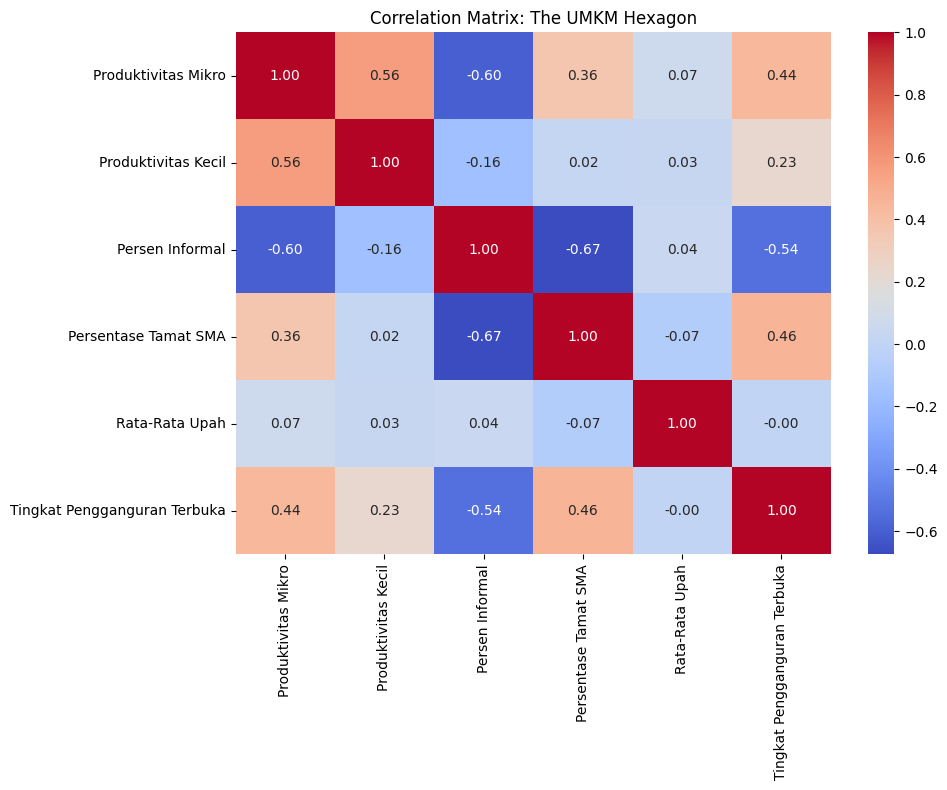

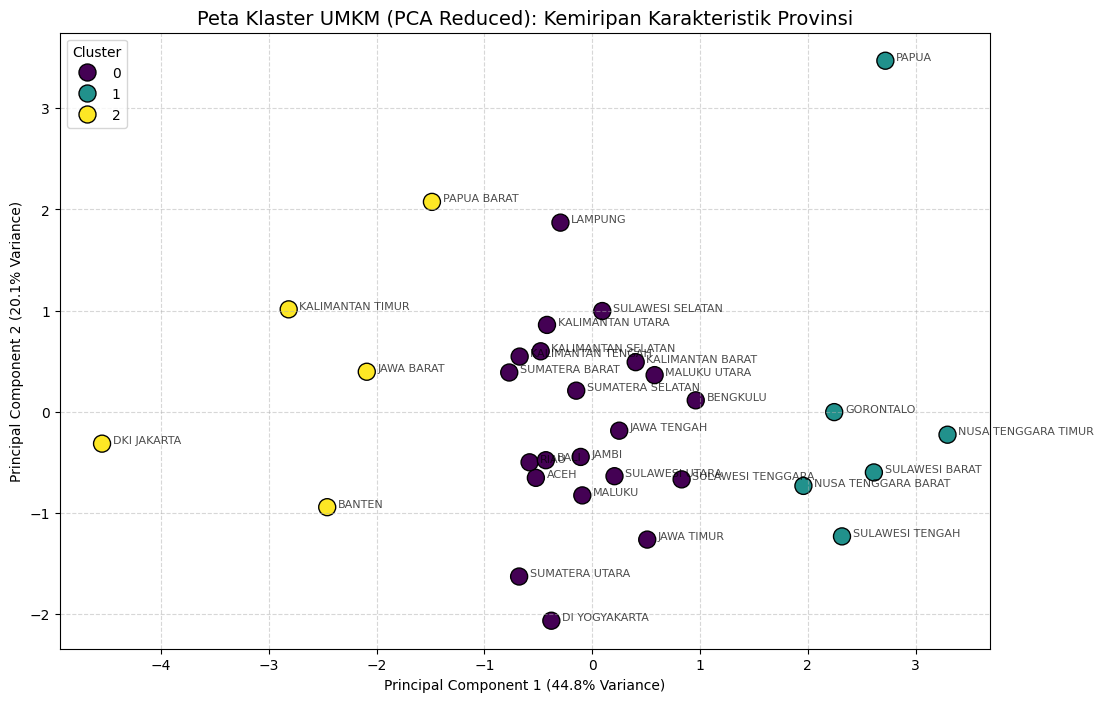


--- PROFIL CLUSTER (RADAR CHART) ---


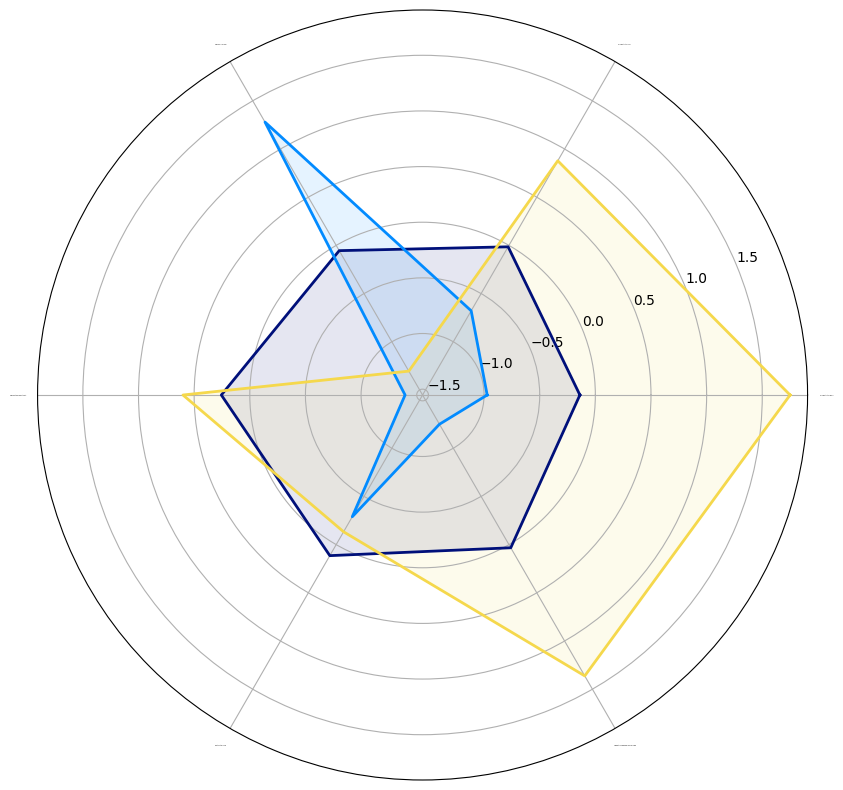


Intepretasi Nilai Rata-Rata Asli per Cluster:
Cluster                                  0             1             2
Produktivitas Mikro           5.228973e+01  3.467834e+01  9.222253e+01
Produktivitas Kecil           1.066139e+02  7.436061e+01  1.499684e+02
Persen Informal               5.990000e+01  7.240333e+01  4.818200e+01
Persentase Tamat SMA          6.800667e+01  5.054833e+01  7.165200e+01
Rata-Rata Upah                3.915743e+06  3.694797e+06  3.780244e+06
Tingkat Pengganguran Terbuka  4.592381e+00  2.815000e+00  6.436000e+00

Anggota Cluster 0:
['ACEH' 'SUMATERA UTARA' 'SUMATERA BARAT' 'RIAU' 'JAMBI'
 'SUMATERA SELATAN' 'BENGKULU' 'LAMPUNG' 'JAWA TENGAH' 'DI YOGYAKARTA'
 'JAWA TIMUR' 'BALI' 'KALIMANTAN BARAT' 'KALIMANTAN TENGAH'
 'KALIMANTAN SELATAN' 'KALIMANTAN UTARA' 'SULAWESI UTARA'
 'SULAWESI SELATAN' 'SULAWESI TENGGARA' 'MALUKU' 'MALUKU UTARA']

Anggota Cluster 1:
['NUSA TENGGARA BARAT' 'NUSA TENGGARA TIMUR' 'SULAWESI TENGAH' 'GORONTALO'
 'SULAWESI BARAT' 'PAPUA']

An

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from math import pi

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
print("--- 1. DATA PREPARATION ---")
df = pd.read_csv('Dataset_Gabungan_UMKM_Provinsi.csv')

# 6 Variabel Terpilih
features = [
    'Produktivitas Mikro', 
    'Produktivitas Kecil',
    'Persen Informal', 
    'Persentase Tamat SMA',
    'Rata-Rata Upah',
    'Tingkat Pengganguran Terbuka'
]

# Cleaning: Drop missing values
df_clean = df.dropna(subset=features).copy()
X = df_clean[features]

print(f"Jumlah Provinsi yang dianalisis: {len(df_clean)}")
print(X.head())

# ==========================================
# 2. SCALING & CORRELATION
# ==========================================
# Standarisasi Data (Z-Score) sangat penting karena satuannya beda (Rupiah vs Persen)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cek Korelasi Antar 6 Variabel
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: The UMKM Hexagon')
plt.tight_layout()
plt.show()

# ==========================================
# 3. CLUSTERING (K-MEANS)
# ==========================================
# Kita gunakan 3 Cluster (Bisa diganti 4 jika ingin lebih detail)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# ==========================================
# 4. VISUALISASI 1: PCA SCATTER PLOT
# ==========================================
# Mereduksi 6 dimensi menjadi 2 dimensi agar bisa digambar di grafik X-Y
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
df_clean['PC1'] = principal_components[:, 0]
df_clean['PC2'] = principal_components[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_clean, x='PC1', y='PC2', 
    hue='Cluster', palette='viridis', s=150, edgecolor='black'
)

# Labeli setiap titik dengan nama Provinsi
for i in range(df_clean.shape[0]):
    plt.text(
        df_clean.PC1.iloc[i]+0.1, 
        df_clean.PC2.iloc[i], 
        df_clean.Provinsi.iloc[i], 
        fontsize=8, alpha=0.7
    )

plt.title('Peta Klaster UMKM (PCA Reduced): Kemiripan Karakteristik Provinsi', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 5. VISUALISASI 2: RADAR CHART (SPIDER PLOT)
# ==========================================
# Ini untuk melihat "Bentuk" atau "Karakter" masing-masing cluster
print("\n--- PROFIL CLUSTER (RADAR CHART) ---")

# Hitung rata-rata tiap variabel per cluster (Data Asli)
cluster_means = df_clean.groupby('Cluster')[features].mean()

# Hitung rata-rata tiap variabel per cluster (Data Scaled - untuk Radar Chart agar seimbang)
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_means), 
    columns=features,
    index=cluster_means.index
)

# Fungsi membuat Radar Chart
def make_radar_chart(df_means, title):
    categories = list(df_means.columns)
    N = len(categories)
    
    # Sudut untuk setiap sumbu
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the loop
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    # Setup Sumbu
    plt.xticks(angles[:-1], categories, color='#000000', size=0)
    
    # Plot setiap cluster
    colors = ['#00107A', '#028BFF', '#F5D84C'] # Biru, Oranye, Hijau
    labels = ['The Deep Sleepers (Tertinggal)', 'The Stirring Giants (Berkembang)', 'The Awakened Leaders (Maju)']
    
    for i, row in df_means.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1] # Close the loop
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=labels[i], color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    
    plt.title(title, size=0, y=1.05)
    #plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

make_radar_chart(cluster_means_scaled, "")

# Print Rata-rata Asli untuk Interpretasi Narasi
print("\nIntepretasi Nilai Rata-Rata Asli per Cluster:")
print(cluster_means.transpose())

# ==========================================
# 6. EXPORT HASIL
# ==========================================
# Tampilkan anggota cluster
for i in range(3):
    print(f"\nAnggota Cluster {i}:")
    print(df_clean[df_clean['Cluster'] == i]['Provinsi'].values)


--- PROFIL CLUSTER (RADAR CHART) - LABEL FIXED OUTSIDE ---


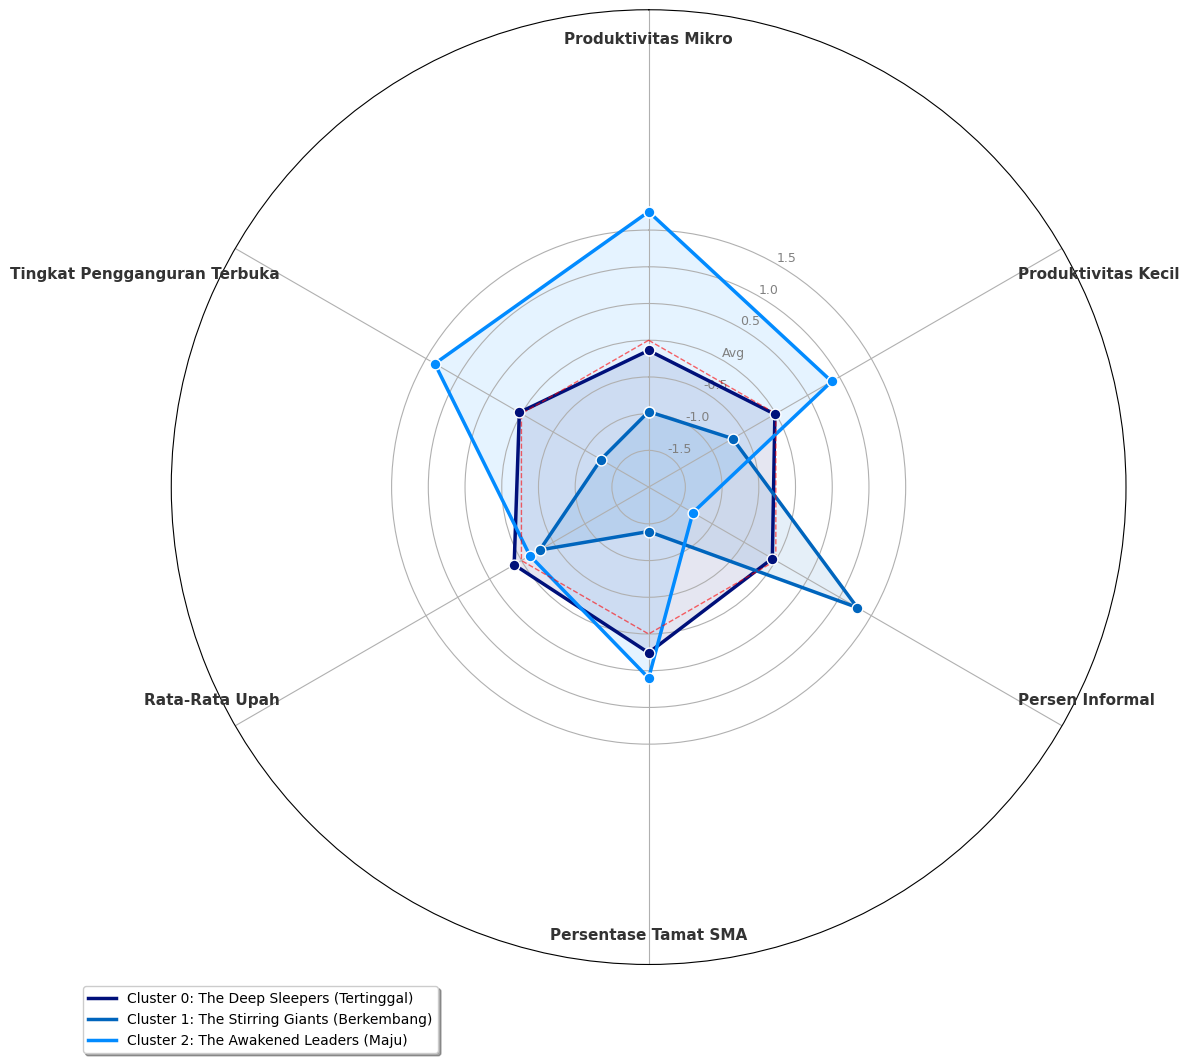

In [2]:
# ==========================================
# VISUALISASI FINAL: POSISI LABEL OUTSIDE
# ==========================================
print("\n--- PROFIL CLUSTER (RADAR CHART) - LABEL FIXED OUTSIDE ---")

# Data tetap sama
cluster_means = df_clean.groupby('Cluster')[features].mean()
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_means), 
    columns=features,
    index=cluster_means.index
)

def make_final_outside_radar(df_means):
    # Persiapan Variabel
    categories = list(df_means.columns)
    N = len(categories)
    
    # Menghitung sudut
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the loop
    
    # Ukuran Figure
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    
    # 1. ATUR ROTASI
    ax.set_theta_offset(pi / 2) # Jam 12
    ax.set_theta_direction(-1) # Searah jarum jam
    
    # 2. HILANGKAN LABEL DEFAULT (KITA PAKAI MANUAL)
    plt.xticks(angles[:-1], [])
    
    # 3. ATUR LIMIT CANVAS (SANGAT PENTING)
    # Kita set batas sangat luas (4.5) agar label di radius 4.0 muat
    ax.set_ylim(-2, 4.5) 

    # 4. TEMPEL LABEL MANUAL (JARAK JAUH / OUTSIDE)
    for label_text, angle in zip(categories, angles[:-1]):
        angle_deg = np.degrees(angle)
        
        if angle_deg == 0: 
            # === LABEL ATAS (Produktivitas Mikro) ===
            # Radius 4.0: Sangat jauh di atas
            r_pos = 4.0 
            ha = 'center'
            va = 'bottom' 
            
        elif angle_deg == 180:
            # === LABEL BAWAH (Tamat SMA) ===
            # Radius 4.0: Sangat jauh di bawah (Di luar lingkaran radar)
            r_pos = 4.0
            ha = 'center'
            va = 'top' 
            
        else:
            # === LABEL SAMPING ===
            # Radius 3.8: Agar seimbang dengan atas bawah
            r_pos = 3.8
            if 0 < angle_deg < 180: # Kanan
                ha = 'left'
            else: # Kiri
                ha = 'right'
            va = 'center'

        # Render Teks
        ax.text(angle, r_pos, label_text, size=11, weight='bold',
                horizontalalignment=ha, verticalalignment=va, color='#333333')

    # 5. LABEL GRID Y (ANGKA)
    ax.set_rlabel_position(30) # Arah jam 1
    plt.yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5], 
               ["-1.5", "-1.0", "-0.5", "Avg", "0.5", "1.0", "1.5"], 
               color="grey", size=9)
    
    # 6. PLOTTING
    colors = ['#00107A', '#0065BD', '#028BFF'] 
    labels = [
        'Cluster 0: The Deep Sleepers (Tertinggal)', 
        'Cluster 1: The Stirring Giants (Berkembang)', 
        'Cluster 2: The Awakened Leaders (Maju)'
    ]
    
    for i, row in df_means.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=labels[i], color=colors[i])
        ax.scatter(angles, values, s=60, color=colors[i], zorder=10, edgecolors='white')
        ax.fill(angles, values, color=colors[i], alpha=0.1)

    # 7. LEGENDA
    plt.legend(loc='lower left', bbox_to_anchor=(-0.1, -0.1), 
               fancybox=True, shadow=True, ncol=1, fontsize=10)

    # Garis Referensi
    ax.plot(angles, [0]*len(angles), linestyle='--', color='red', linewidth=1, alpha=0.6)
    
    plt.tight_layout()
    plt.show()

make_final_outside_radar(cluster_means_scaled)

--- 1. LOADING & CLEANING DATA ---
Data siap dianalisis: 32 Provinsi

--- 2. OPTIMASI K DENGAN PCA ---
PCA mereduksi fitur dari 6 menjadi 5 komponen utama.


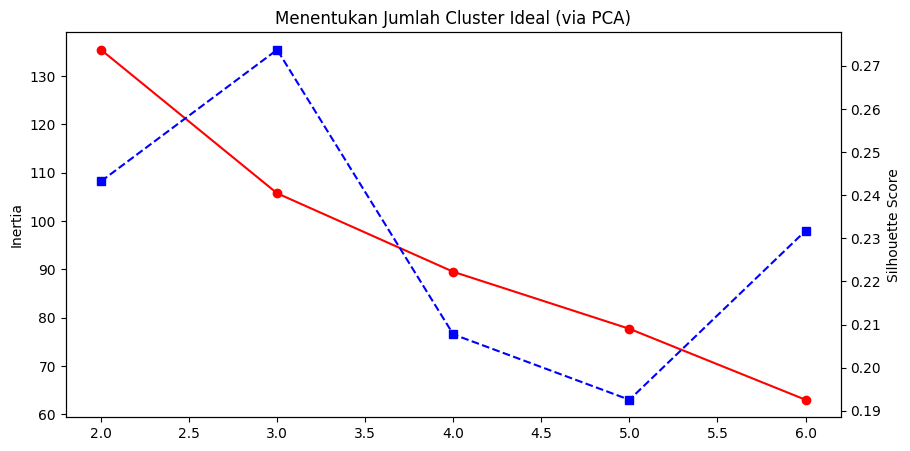

Jumlah Cluster Terbaik: k=3

--- 3. CLUSTERING (k=3) ---
         Provinsi                          Category
0            ACEH  The Stirring Giants (Berkembang)
1  SUMATERA UTARA  The Stirring Giants (Berkembang)
2  SUMATERA BARAT  The Stirring Giants (Berkembang)
3            RIAU  The Stirring Giants (Berkembang)
4           JAMBI  The Stirring Giants (Berkembang)

--- 4. VISUALISASI PETA ---


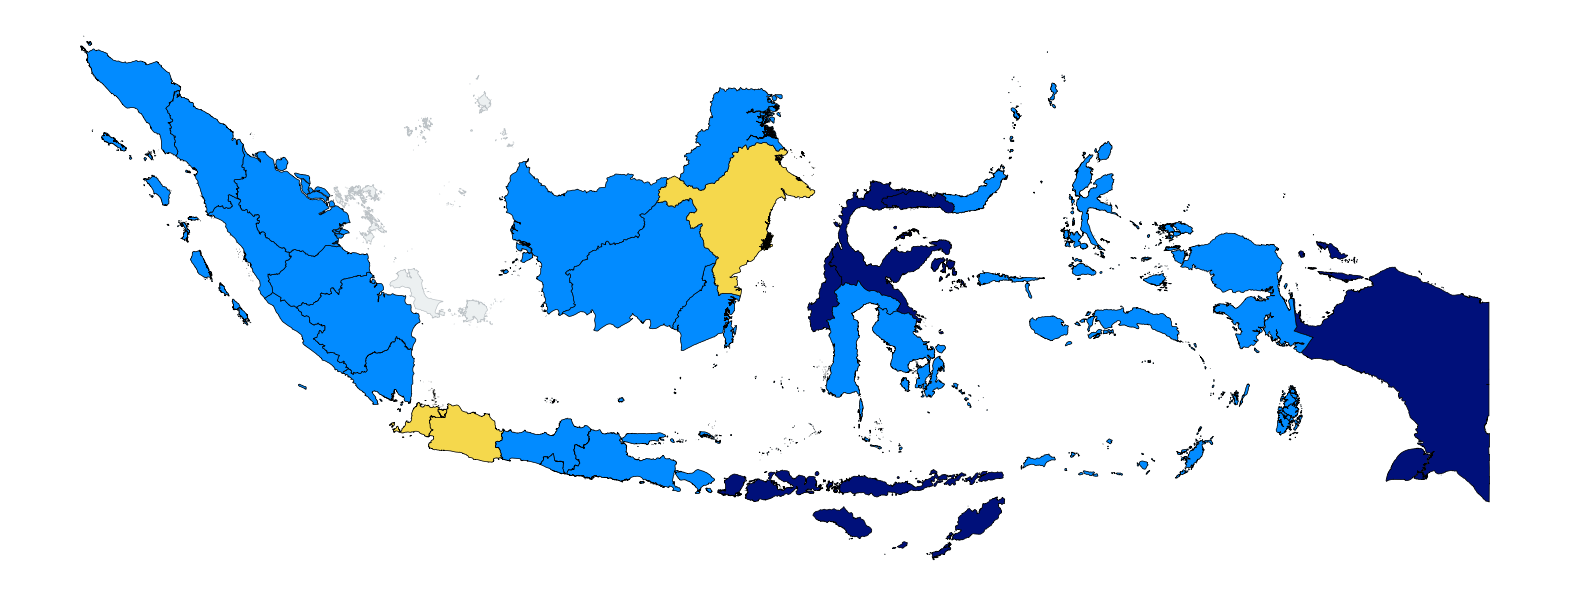

✅ Peta berhasil disimpan: Peta_Cluster_UMKM_Fixed.png

[INFO] Provinsi di Peta yang datanya kosong (Cek Mapping Nama):
['BANGKA BELITUNG' 'KEPULAUAN RIAU']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import geopandas as gpd # Pastikan library ini terinstall

# ==========================================
# 1. SETUP & DATA CLEANING
# ==========================================
# Path sesuai permintaan Anda
csv_path = 'Dataset_Gabungan_UMKM_Provinsi.csv'
shp_path = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp"

print("--- 1. LOADING & CLEANING DATA ---")
df = pd.read_csv(csv_path)

# 1.A. Buang baris "Sampah" (Catatan kaki, angka urut, dll)
# Kita hanya ambil baris yang nama provinsinya panjang (valid) dan tidak diawali angka
df_clean = df[df['Provinsi'].astype(str).str.len() > 3].copy()
df_clean = df_clean[~df_clean['Provinsi'].astype(str).str.match(r'^\d')]
df_clean = df_clean[~df_clean['Provinsi'].isin(['RATA-RATA', 'CATATAN:', 'TOTAL', 'INDONESIA'])]

# 1.B. Standarisasi Nama Provinsi (Agar match dengan GADM Shapefile)
# Dictionary ini memetakan Nama BPS (CSV) -> Nama GADM (SHP)
province_mapper = {
    'DKI JAKARTA': 'JAKARTA RAYA',
    'DI YOGYAKARTA': 'YOGYAKARTA',
    'KEP. BANGKA BELITUNG': 'BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'NUSA TENGGARA BARAT': 'NUSA TENGGARA BARAT',
    'NUSA TENGGARA TIMUR': 'NUSA TENGGARA TIMUR',
    # Tambahkan mapping lain jika masih ada yang abu-abu di peta
}

# Terapkan mapping, jika tidak ada di dict, biarkan nama aslinya
df_clean['Provinsi_Map'] = df_clean['Provinsi'].replace(province_mapper)

# Pilih 6 Variabel Hexagon
features = [
    'Produktivitas Mikro', 
    'Produktivitas Kecil',
    'Persen Informal', 
    'Persentase Tamat SMA',
    'Rata-Rata Upah',
    'Tingkat Pengganguran Terbuka'
]

# Drop missing values
df_model = df_clean.dropna(subset=features).copy()
print(f"Data siap dianalisis: {len(df_model)} Provinsi")

# ==========================================
# 2. PCA & K DETERMINATION (ELBOW METHOD)
# ==========================================
print("\n--- 2. OPTIMASI K DENGAN PCA ---")

# Scaling Data (Wajib)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features])

# PCA: Reduksi dimensi untuk melihat variance
pca = PCA(n_components=0.95) # Ambil komponen yang menjelaskan 95% variansi
X_pca = pca.fit_transform(X_scaled)
print(f"PCA mereduksi fitur dari {X_scaled.shape[1]} menjadi {X_pca.shape[1]} komponen utama.")

# Mencari K Terbaik (Elbow & Silhouette) pada data PCA
inertia = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))

# Plot Elbow
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, 'o-', color='r', label='Inertia (Elbow)')
ax1.set_ylabel('Inertia')
ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 's--', color='b', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score')
plt.title('Menentukan Jumlah Cluster Ideal (via PCA)')
plt.show()

# Pilih K terbaik otomatis berdasarkan Silhouette Score tertinggi
best_k = K_range[np.argmax(sil_scores)]
# Override manual jika ingin sesuai narasi (misal k=3)
if best_k != 3: 
    print(f"Saran Algoritma k={best_k}, namun kita gunakan k=3 untuk narasi Sleeping Giant.")
    best_k = 3
else:
    print(f"Jumlah Cluster Terbaik: k={best_k}")

# ==========================================
# 3. CLUSTERING & PROFILING
# ==========================================
print(f"\n--- 3. CLUSTERING (k={best_k}) ---")

# Final Clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_model['Cluster'] = kmeans.fit_predict(X_pca) # Clustering pada data PCA

# Profiling: Urutkan Cluster berdasarkan Produktivitas (Low -> High)
# Ini agar Cluster 0 selalu "Low", Cluster 1 "Mid", dst.
mean_prod = df_model.groupby('Cluster')['Produktivitas Mikro'].mean().sort_values()
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(mean_prod.index)}
df_model['Cluster_Sorted'] = df_model['Cluster'].map(cluster_mapping)

# Beri Label Naratif
labels = ['The Deep Sleepers (Tertinggal)', 'The Stirring Giants (Berkembang)', 'The Awakened Leaders (Maju)']
colors = ['#00107A', '#028BFF', '#F5D84C'] # Merah, Kuning, Hijau

df_model['Category'] = df_model['Cluster_Sorted'].apply(lambda x: labels[x] if x < 3 else f'Cluster {x}')
df_model['Color'] = df_model['Cluster_Sorted'].apply(lambda x: colors[x] if x < 3 else 'gray')

print(df_model[['Provinsi', 'Category']].head())

# ==========================================
# 4. VISUALISASI PETA (GEOPANDAS)
# ==========================================
print("\n--- 4. VISUALISASI PETA ---")

try:
    # Load SHP
    gdf = gpd.read_file(shp_path)
    
    # Standarisasi Nama di SHP (Upper case)
    # Cek kolom nama provinsi di SHP Anda, biasanya 'NAME_1'
    gdf['NAME_1'] = gdf['NAME_1'].str.upper()
    
    # Merge Data (Left Join ke Peta)
    # Gunakan 'Provinsi_Map' yang sudah distandarisasi
    gdf_merged = gdf.merge(df_model, left_on='NAME_1', right_on='Provinsi_Map', how='left')
    
    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(20, 12))
    
    # 1. Base Layer (Peta Kosong - Abu-abu)
    gdf.plot(ax=ax, color='#ecf0f1', edgecolor='#bdc3c7', linewidth=0.5)
    
    # 2. Data Layer (Warna Warni sesuai Cluster)
    # Hanya plot yang datanya ada
    gdf_data = gdf_merged.dropna(subset=['Category'])
    gdf_data.plot(
        ax=ax, 
        color=gdf_data['Color'], 
        edgecolor='black', 
        linewidth=0.5,
        legend=False
    )
    
    # 3. Custom Legend
    from matplotlib.patches import Patch
    #legend_elements = [Patch(facecolor=colors[i], edgecolor='k', label=labels[i]) for i in range(best_k)]
    #ax.legend(handles=legend_elements, loc='lower left', title='Status Transformasi UMKM', fontsize=12)
    
    # plt.title(f'Peta Segmentasi Kesehatan UMKM Indonesia 2023\n(Clustering Based on 6 Key Indicators)', fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Simpan
    output_filename = 'Peta_Cluster_UMKM_Fixed.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Peta berhasil disimpan: {output_filename}")
    
    # Cek Provinsi yang Gagal di-Merge (Masih Abu-abu)
    missing_provs = gdf_merged[gdf_merged['Category'].isna()]['NAME_1'].unique()
    print("\n[INFO] Provinsi di Peta yang datanya kosong (Cek Mapping Nama):")
    print(missing_provs)

except Exception as e:
    print(f"\n❌ TERJADI ERROR PADA PETA: {e}")
    print("Tips Debugging:")
    print("1. Pastikan path SHP benar dan file .shx/.dbf ada di folder yang sama.")
    print("2. Cek nama kolom provinsi di SHP Anda (apakah 'NAME_1' atau 'PROVINSI'?).")
    print("3. Install library: pip install geopandas mapclassify")

# Regresi Spasial

--- 1. DATA PREPARATION ---
Jumlah Observasi untuk Model: 32 Provinsi

--- 2. EDA & SPATIAL DISTRIBUTION ---


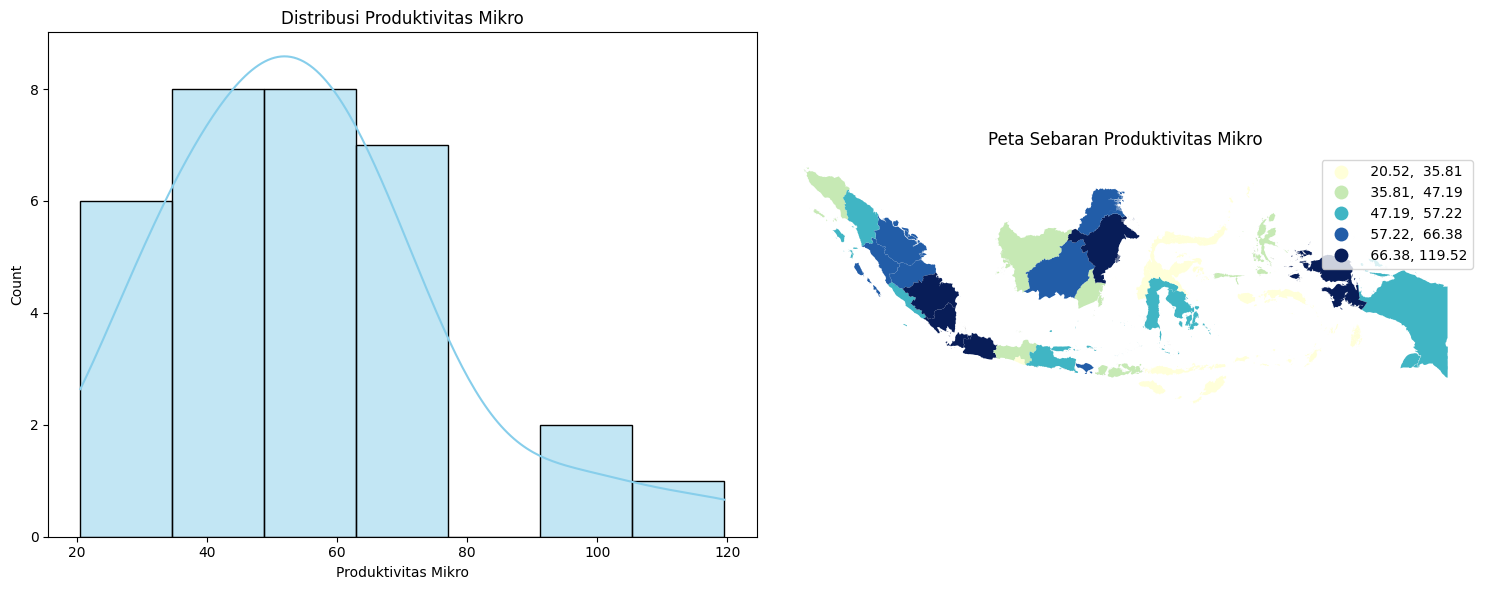

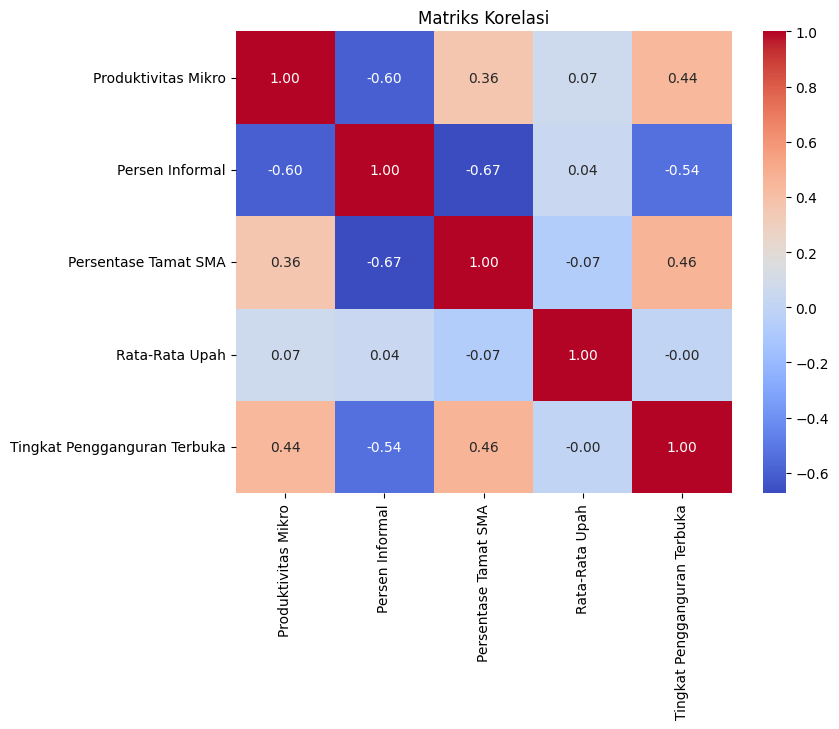


--- 3. SPATIAL WEIGHTS MATRIX ---
Weight Matrix Created using KNN (k=4). N: 32, Mean Neighbors: 4.0

--- 4. TEST SPATIAL AUTOCORRELATION (MORAN'S I) ---
Moran's I Value: 0.1602
P-Value: 0.0590
KESIMPULAN: Data menyebar acak. (Cukup pakai OLS biasa)

--- 5. SPATIAL REGRESSION MODELING ---

>>> OLS DIAGNOSTICS:
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :   UMKM Data
Weights matrix      :     unknown
Dependent Variable  :Produktivitas Mikro                Number of Observations:          32
Mean dependent var  :     55.2271                Number of Variables   :           5
S.D. dependent var  :     21.4809                Degrees of Freedom    :          27
R-squared           :      0.3946
Adjusted R-squared  :      0.3049
Sum squared residual:     8659.36                F-statistic           :      4.4002
Sigma-square        :     320.717                Prob(F-statistic)     :    0.0072

C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


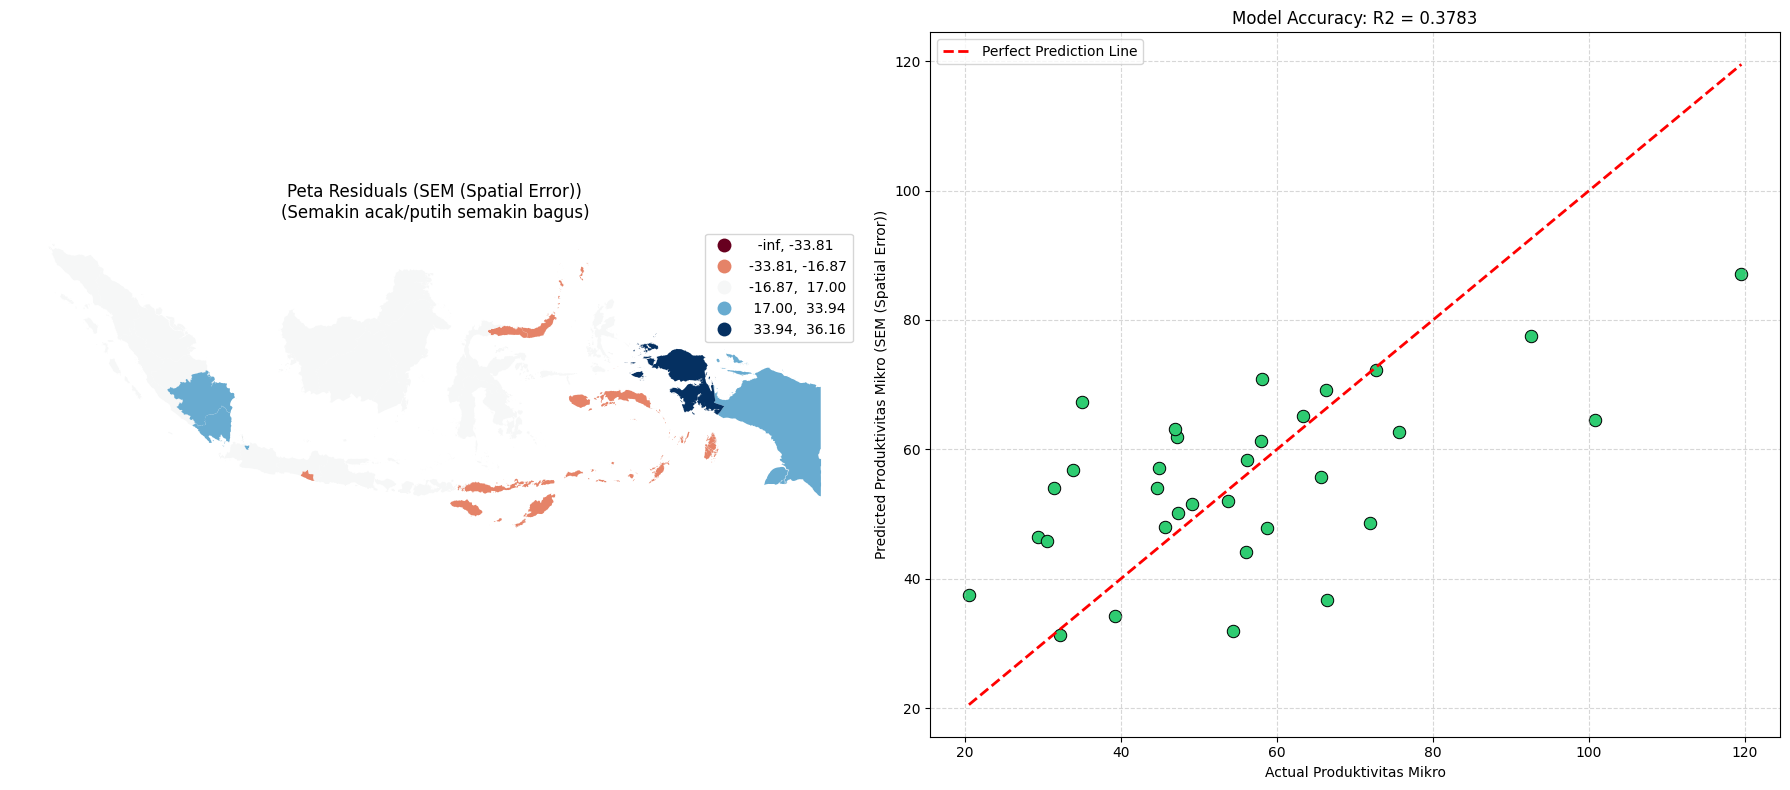

✅ Visualisasi berhasil diperbaiki.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from libpysal import weights
from esda.moran import Moran
import spreg
from spreg import OLS, ML_Lag, ML_Error

# ==============================================================================
# 1. SETUP, LOADING & PREPROCESSING (Sama seperti sebelumnya)
# ==============================================================================
print("--- 1. DATA PREPARATION ---")

# Load Data
csv_path = 'Dataset_Gabungan_UMKM_Provinsi.csv'
# Gunakan path file SHP lokal Anda
shp_path = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp"

df = pd.read_csv(csv_path)
gdf = gpd.read_file(shp_path)

# A. Cleaning & Filtering
# Kita bersihkan baris sampah dan ambil hanya provinsi valid
df_clean = df[df['Provinsi'].astype(str).str.len() > 3].copy()
df_clean = df_clean[~df_clean['Provinsi'].astype(str).str.match(r'^\d')]
df_clean = df_clean[~df_clean['Provinsi'].isin(['RATA-RATA', 'CATATAN:', 'TOTAL', 'INDONESIA'])]

# B. Mapping Nama Provinsi (Standardisasi)
province_mapper = {
    'DKI JAKARTA': 'JAKARTA RAYA',
    'DI YOGYAKARTA': 'YOGYAKARTA',
    'KEP. BANGKA BELITUNG': 'BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
}
df_clean['Provinsi_Map'] = df_clean['Provinsi'].replace(province_mapper)
gdf['NAME_1'] = gdf['NAME_1'].str.upper() # Pastikan SHP juga upper case

# C. Merge Dataframe dengan Shapefile (Wajib untuk analisis spasial)
gdf_final = gdf.merge(df_clean, left_on='NAME_1', right_on='Provinsi_Map', how='inner')

# D. Tentukan Variabel Model
# Y = Dependent (Produktivitas Mikro)
# X = Independent (Informalitas, Pendidikan, Upah, Pengangguran)
variable_y = 'Produktivitas Mikro'
variables_x = ['Persen Informal', 'Persentase Tamat SMA', 'Rata-Rata Upah', 'Tingkat Pengganguran Terbuka']

# Drop missing values
gdf_model = gdf_final.dropna(subset=[variable_y] + variables_x).copy()
print(f"Jumlah Observasi untuk Model: {len(gdf_model)} Provinsi")

# ==============================================================================
# 2. EDA: EXPLORATORY DATA ANALYSIS
# ==============================================================================
print("\n--- 2. EDA & SPATIAL DISTRIBUTION ---")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Histogram Variabel Y
sns.histplot(gdf_model[variable_y], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title(f'Distribusi {variable_y}')

# Peta Sebaran Y
gdf_model.plot(column=variable_y, scheme='quantiles', k=5, cmap='YlGnBu', legend=True, ax=ax[1])
ax[1].set_title(f'Peta Sebaran {variable_y}')
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Matriks Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(gdf_model[[variable_y] + variables_x].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

# ==============================================================================
# 3. MEMBUAT SPATIAL WEIGHTS MATRIX (W)
# ==============================================================================
print("\n--- 3. SPATIAL WEIGHTS MATRIX ---")
# Kunci analisis spasial: Mendefinisikan "Siapa Tetangga Siapa?"
# Karena Indonesia Kepulauan, Queen/Rook Contiguity akan gagal (pulau terpisah laut).
# SOLUSI: Gunakan KNN (k-Nearest Neighbors). Kita asumsikan 4 tetangga terdekat.

w = weights.KNN.from_dataframe(gdf_model, k=4)
w.transform = 'r' # Row-standardization

print(f"Weight Matrix Created using KNN (k=4). N: {w.n}, Mean Neighbors: {w.mean_neighbors}")

# ==============================================================================
# 4. UJI DEPENDENSI SPASIAL (MORAN'S I)
# ==============================================================================
print("\n--- 4. TEST SPATIAL AUTOCORRELATION (MORAN'S I) ---")

y = gdf_model[variable_y].values
moran = Moran(y, w)

print(f"Moran's I Value: {moran.I:.4f}")
print(f"P-Value: {moran.p_sim:.4f}")

if moran.p_sim < 0.05:
    print("KESIMPULAN: Terdapat Autokorelasi Spasial Signifikan. (Regresi Spasial Diperlukan!)")
else:
    print("KESIMPULAN: Data menyebar acak. (Cukup pakai OLS biasa)")

# ==============================================================================
# 5. PEMODELAN & EVALUASI (OLS vs SAR vs SEM)
# ==============================================================================
print("\n--- 5. SPATIAL REGRESSION MODELING ---")

# Siapkan Array X dan Y
Y = gdf_model[[variable_y]].values
X = gdf_model[variables_x].values

# MODEL A: OLS (Ordinary Least Squares) - Baseline
ols = OLS(Y, X, w=w, name_y=variable_y, name_x=variables_x, name_ds='UMKM Data')
print("\n>>> OLS DIAGNOSTICS:")
# Cek Lagrange Multiplier (LM) Tests untuk menentukan arah model
# Jika LM-Lag signifikan -> Pakai Spatial Lag (SAR)
# Jika LM-Error signifikan -> Pakai Spatial Error (SEM)
print(ols.summary)

# MODEL B: SPATIAL LAG MODEL (SAR) - "Tetangga Mempengaruhi Tetangga"
# Interpretasi: Produktivitas Jabar dipengaruhi oleh Produktivitas Jakarta.
sar = ML_Lag(Y, X, w=w, name_y=variable_y, name_x=variables_x, name_ds='UMKM Data')

# MODEL C: SPATIAL ERROR MODEL (SEM) - "Error yang Berkorelasi"
# Interpretasi: Ada faktor tak terlihat (budaya/iklim) yang mirip antar wilayah.
sem = ML_Error(Y, X, w=w, name_y=variable_y, name_x=variables_x, name_ds='UMKM Data')

# ==============================================================================
# 6. EVALUASI MODEL TERBAIK (AIC COMPARISON)
# ==============================================================================
print("\n--- 6. MODEL EVALUATION (AIC COMPARISON) ---")

models = {'OLS': ols, 'SAR (Spatial Lag)': sar, 'SEM (Spatial Error)': sem}
results = []

for name, model in models.items():
    results.append({
        'Model': name,
        'AIC': model.aic,
        'Log Likelihood': model.logll,
        'R2 (Pseudo)': model.pr2 if name != 'OLS' else model.r2
    })

df_res = pd.DataFrame(results).sort_values('AIC')
print(df_res)

best_model_name = df_res.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n🏆 BEST MODEL: {best_model_name} (Lowest AIC)")
print(best_model.summary) # Cetak detail model terbaik

# ==============================================================================
# 7. VISUALISASI HASIL & RESIDUAL (PERBAIKAN)
# ==============================================================================
print(f"\n--- 7. VISUALIZING {best_model_name} RESULTS ---")

# 1. Ambil Residuals (Error)
# spreg menyimpan residuals di atribut 'u'
gdf_model['Residuals'] = best_model.u

# 2. Ambil Prediksi (Fitted Values)
# Perbaikan logika: ML_Error (SEM) pakai .predy, ML_Lag (SAR) pakai .predy_e
try:
    if hasattr(best_model, 'predy_e'):
        y_pred = best_model.predy_e # Khusus Spatial Lag
    else:
        y_pred = best_model.predy   # OLS dan Spatial Error (SEM)
except:
    # Fallback jika atribut beda versi library
    y_pred = best_model.predy

# 3. Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# A. Peta Residuals
# Gunakan skema warna diverging (Merah-Putih-Biru) untuk melihat pola
gdf_model.plot(column='Residuals', scheme='std_mean', cmap='RdBu', legend=True, ax=ax[0])
ax[0].set_title(f'Peta Residuals ({best_model_name})\n(Semakin acak/putih semakin bagus)')
ax[0].axis('off')

# B. Scatter Plot Prediksi vs Aktual
# Flatten y_pred karena output spreg adalah array 2D (n, 1)
sns.scatterplot(x=gdf_model[variable_y], y=y_pred.flatten(), ax=ax[1], color='#2ecc71', s=80, edgecolor='black')

# Garis referensi 45 derajat (Perfect Fit)
min_val = min(gdf_model[variable_y].min(), y_pred.min())
max_val = max(gdf_model[variable_y].max(), y_pred.max())
ax[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction Line', linewidth=2)

# Labeling
ax[1].set_xlabel(f'Actual {variable_y}')
ax[1].set_ylabel(f'Predicted {variable_y} ({best_model_name})')
ax[1].set_title(f'Model Accuracy: R2 = {df_res.loc[df_res["Model"]==best_model_name, "R2 (Pseudo)"].values[0]:.4f}')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Visualisasi berhasil diperbaiki.")

--- 1. DATA PREPARATION ---

--- 2. APPLYING LOG TRANSFORMATION ---
Model menggunakan 32 provinsi.


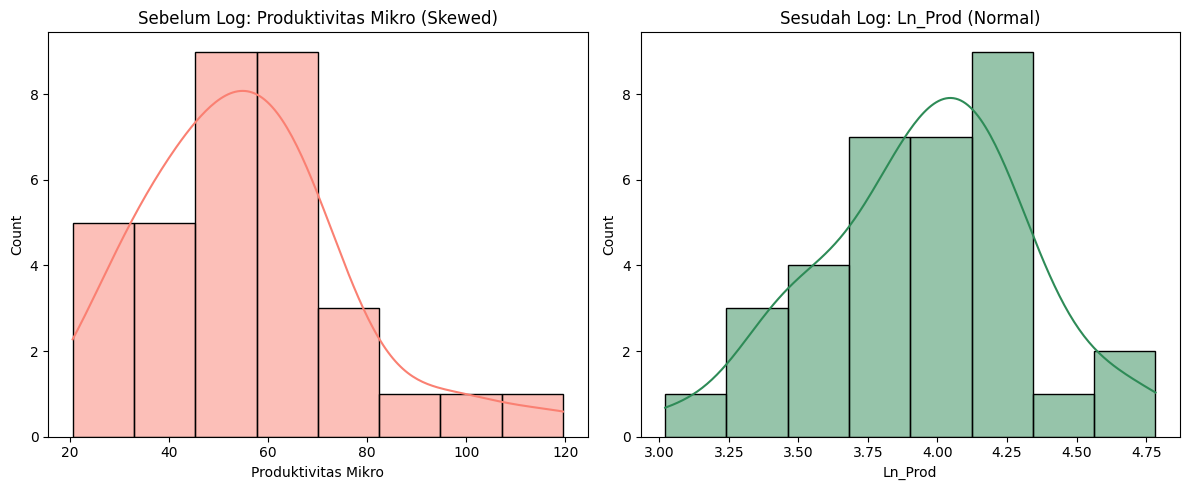


--- 3. SPATIAL REGRESSION (LOG-LEVEL MODEL) ---

--- 4. MODEL COMPARISON (AIC) ---
       Model        AIC        R2
2  SEM (Log)  20.994505  0.318726
0  OLS (Log)  23.514617  0.332288
1  SAR (Log)  23.699939  0.381944

🏆 BEST MODEL: SEM (Log)
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :    UMKM Log
Weights matrix      :     unknown
Dependent Variable  :     Ln_Prod                Number of Observations:          32
Mean dependent var  :      3.9412                Number of Variables   :           4
S.D. dependent var  :      0.3834                Degrees of Freedom    :          28
Pseudo R-squared    :      0.3187
Log likelihood      :     -6.4973
Sigma-square ML     :      0.0848                Akaike info criterion :      20.995
S.E of regression   :      0.2912                Schwarz criterion     :      26.857

--------------------------------------------------

C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


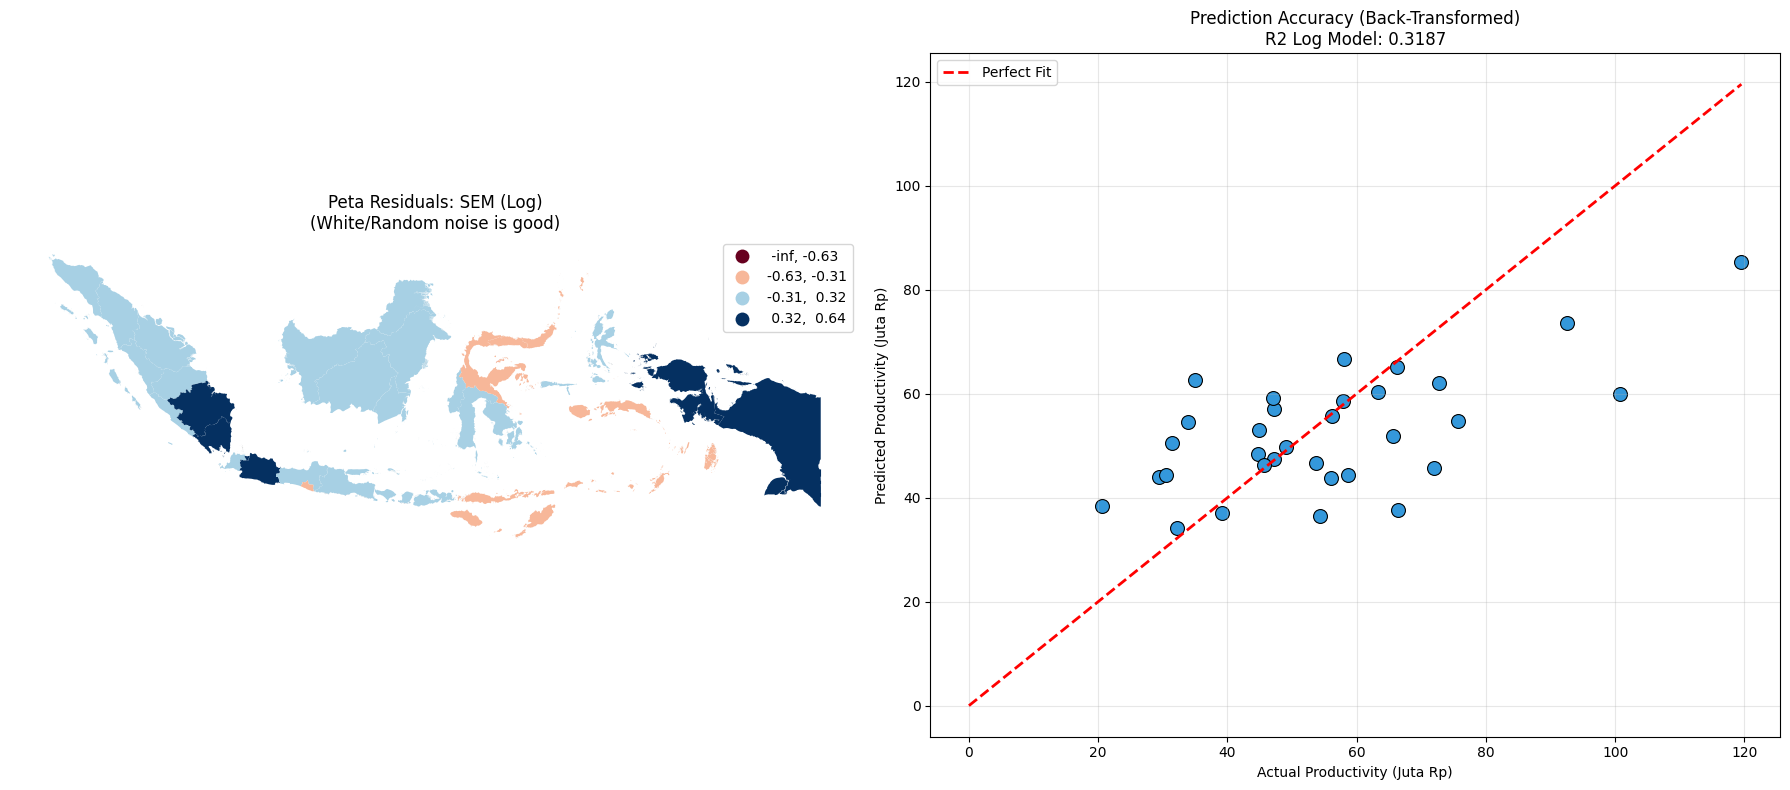


--- 6. CARA MEMBACA KOEFISIEN (PENTING) ---
Karena Y di-Log dan X (Informal) adalah Persen (Linear), interpretasinya:
>> 'Semi-Elasticity': 1 Unit kenaikan X (1%) berhubungan dengan (Beta * 100)% perubahan pada Y.

Cek Koefisien 'Persen_Informal_2023' di tabel summary di atas.
Contoh: Jika Beta = -0.02
Artinya: Kenaikan informalitas sebesar 1% akan menurunkan produktivitas sebesar 2%.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from libpysal import weights
from spreg import OLS, ML_Lag, ML_Error

# ==============================================================================
# 1. SETUP, LOADING & CLEANING
# ==============================================================================
print("--- 1. DATA PREPARATION ---")

# Path File
csv_path = 'Dataset_Gabungan_UMKM_Provinsi.csv'
shp_path = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp"

# Load Data
df = pd.read_csv(csv_path)
try:
    gdf = gpd.read_file(shp_path)
except Exception as e:
    print(f"Error loading SHP: {e}. Pastikan path benar.")
    # Stop execution if SHP fails since spatial regression needs it
    raise

# Cleaning CSV (Hapus baris sampah)
df_clean = df[df['Provinsi'].astype(str).str.len() > 3].copy()
df_clean = df_clean[~df_clean['Provinsi'].astype(str).str.match(r'^\d')]
df_clean = df_clean[~df_clean['Provinsi'].isin(['RATA-RATA', 'CATATAN:', 'TOTAL', 'INDONESIA'])]

# Mapping Nama Provinsi (Agar match dengan GADM SHP)
province_mapper = {
    'DKI JAKARTA': 'JAKARTA RAYA',
    'DI YOGYAKARTA': 'YOGYAKARTA',
    'KEP. BANGKA BELITUNG': 'BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'NUSA TENGGARA BARAT': 'NUSA TENGGARA BARAT',
    'NUSA TENGGARA TIMUR': 'NUSA TENGGARA TIMUR'
}
df_clean['Provinsi_Map'] = df_clean['Provinsi'].replace(province_mapper)
gdf['NAME_1'] = gdf['NAME_1'].str.upper()

# Merge Data
gdf_final = gdf.merge(df_clean, left_on='NAME_1', right_on='Provinsi_Map', how='inner')

# ==============================================================================
# 2. TRANSFORMASI LOGARITMA (THE UPGRADE)
# ==============================================================================
print("\n--- 2. APPLYING LOG TRANSFORMATION ---")

# Variabel Asli
y_raw = 'Produktivitas Mikro'
x_raw_upah = 'Rata-Rata Upah'

# Terapkan Natural Logarithm (Ln)
# Kita tambah variabel baru dengan prefix 'Ln_'
gdf_final['Ln_Prod'] = np.log(gdf_final[y_raw])
gdf_final['Ln_Upah'] = np.log(gdf_final[x_raw_upah])

# Definisikan Variabel Model Baru
# Y = Ln(Produktivitas)
# X = Informalitas (%), SMA (%), Ln(Upah)
variable_y = 'Ln_Prod'
variables_x = ['Persen Informal', 'Persentase Tamat SMA', 'Ln_Upah']

# Drop missing values
gdf_model = gdf_final.dropna(subset=[variable_y] + variables_x).copy()
print(f"Model menggunakan {len(gdf_model)} provinsi.")

# Visualisasi Perbandingan Distribusi (Before vs After)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(gdf_final[y_raw], kde=True, ax=ax[0], color='salmon')
ax[0].set_title(f'Sebelum Log: {y_raw} (Skewed)')
sns.histplot(gdf_final[variable_y], kde=True, ax=ax[1], color='seagreen')
ax[1].set_title(f'Sesudah Log: {variable_y} (Normal)')
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. SPATIAL WEIGHTS & MODELING
# ==============================================================================
print("\n--- 3. SPATIAL REGRESSION (LOG-LEVEL MODEL) ---")

# Buat Weight Matrix (KNN k=4)
w = weights.KNN.from_dataframe(gdf_model, k=4)
w.transform = 'r'

# Siapkan Array Numpy
Y = gdf_model[[variable_y]].values
X = gdf_model[variables_x].values

# --- JALANKAN 3 MODEL SEKALIGUS ---
# 1. OLS (Ordinary Least Squares) - Log Transformed
ols = OLS(Y, X, w=w, name_y=variable_y, name_x=variables_x, name_ds='UMKM Log')

# 2. SAR (Spatial Lag)
sar = ML_Lag(Y, X, w=w, name_y=variable_y, name_x=variables_x, name_ds='UMKM Log')

# 3. SEM (Spatial Error)
sem = ML_Error(Y, X, w=w, name_y=variable_y, name_x=variables_x, name_ds='UMKM Log')

# ==============================================================================
# 4. EVALUASI MODEL TERBAIK
# ==============================================================================
print("\n--- 4. MODEL COMPARISON (AIC) ---")

results = [
    {'Model': 'OLS (Log)', 'AIC': ols.aic, 'R2': ols.r2, 'Object': ols},
    {'Model': 'SAR (Log)', 'AIC': sar.aic, 'R2': sar.pr2, 'Object': sar},
    {'Model': 'SEM (Log)', 'AIC': sem.aic, 'R2': sem.pr2, 'Object': sem}
]

df_res = pd.DataFrame(results).sort_values('AIC')
print(df_res[['Model', 'AIC', 'R2']])

best_model_name = df_res.iloc[0]['Model']
best_model = df_res.iloc[0]['Object']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(best_model.summary)

# ==============================================================================
# 5. VISUALISASI HASIL AKHIR
# ==============================================================================
print(f"\n--- 5. VISUALIZING RESULTS ---")

# Ambil Prediksi (Dalam Skala Log)
try:
    if hasattr(best_model, 'predy_e'): # SAR
        y_pred_log = best_model.predy_e
    else: # OLS / SEM
        y_pred_log = best_model.predy
except:
    y_pred_log = best_model.predy

# Kembalikan ke Skala Asli (Rupiah) untuk Interpretasi Manusia
# e^(Ln_Y) = Y
y_pred_actual = np.exp(y_pred_log)
y_actual = np.exp(Y)

# Simpan Residuals ke Dataframe untuk Peta
gdf_model['Residuals'] = best_model.u

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# A. Peta Residuals
gdf_model.plot(column='Residuals', scheme='std_mean', cmap='RdBu', legend=True, ax=ax[0])
ax[0].set_title(f'Peta Residuals: {best_model_name}\n(White/Random noise is good)')
ax[0].axis('off')

# B. Scatter Plot: Prediksi vs Aktual (Skala Asli Rupiah)
sns.scatterplot(x=y_actual.flatten(), y=y_pred_actual.flatten(), ax=ax[1], color='#3498db', s=100, edgecolor='k')

# Garis Perfect Fit
max_val = max(y_actual.max(), y_pred_actual.max())
ax[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect Fit', linewidth=2)

ax[1].set_xlabel('Actual Productivity (Juta Rp)')
ax[1].set_ylabel('Predicted Productivity (Juta Rp)')
ax[1].set_title(f'Prediction Accuracy (Back-Transformed)\nR2 Log Model: {df_res.iloc[0]["R2"]:.4f}')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. INTERPRETASI KOEFISIEN (LOG MODEL)
# ==============================================================================
print("\n--- 6. CARA MEMBACA KOEFISIEN (PENTING) ---")
print("Karena Y di-Log dan X (Informal) adalah Persen (Linear), interpretasinya:")
print(">> 'Semi-Elasticity': 1 Unit kenaikan X (1%) berhubungan dengan (Beta * 100)% perubahan pada Y.")
print("\nCek Koefisien 'Persen_Informal_2023' di tabel summary di atas.")
print("Contoh: Jika Beta = -0.02")
print("Artinya: Kenaikan informalitas sebesar 1% akan menurunkan produktivitas sebesar 2%.")